In [20]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml
from datetime import datetime
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import json
import copy
import random
import math
import time
import shutil
import glob
import logging
from collections import defaultdict
from typing import List, Dict, Tuple, Any

In [21]:
# Load configuration from YAML file
with open('configs/paths.yml', 'r') as f:
    dir_cfg = yaml.safe_load(f)
# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# 1. Load and preprocess data

In [22]:
# load and preprocess data
import tifffile as tf
volume_org = tf.imread(dir_cfg['data']['volume'])
# Normalise the volume to [0, 1]
volume = (volume_org - volume_org.min()) / (volume_org.max() - volume_org.min())
# Convert to PyTorch tensor and add channel dimension
volume = torch.from_numpy(volume).float().unsqueeze(0)  # Shape: (1, D, H, W)
# write in a data_log file the shape and dtype of the volume
with open(os.path.join(dir_cfg['logs_dir']['root'], 'data_log.txt'), 'w') as f:
    f.write(f"Volume shape: {volume.shape}\n")
    f.write(f"Volume dtype: {volume.dtype}\n")
    f.write(f"original volume min: {volume_org.min()}\n")
    f.write(f"original volume max: {volume_org.max()}\n")
    f.write(f"Volume min: {volume.min().item()}\n")
    f.write(f"Volume max: {volume.max().item()}\n")

In [23]:
# Create coordinate grid
D, H, W = volume.shape[1:]  # Get spatial dimensions
# Axes in shape order: z (D), y (H), x (W) — must match SirenDataset convention
z = torch.linspace(-1, 1, D)
y = torch.linspace(-1, 1, H)
x = torch.linspace(-1, 1, W)
zz, yy, xx = torch.meshgrid(z, y, x, indexing='ij')
coords = torch.stack([zz, yy, xx], dim=-1)  # (D, H, W, 3)  — z, y, x order
coords = coords.view(-1, 3)                 # (N, 3)
values = volume.view(-1, 1)                 # (N, 1)
with open(os.path.join(dir_cfg['logs_dir']['root'], 'data_log.txt'), 'a') as f:
    f.write(f'Coordinate grid shape: {coords.shape}\n')
    f.write(f'Values shape: {values.shape}\n')


In [24]:
from src.siren.siren import SirenModel

siren_models = os.listdir(dir_cfg['logs_dir']['siren']['root'] + 'pretrained')
siren_models = sorted([m for m in siren_models if os.path.isdir(
    os.path.join(dir_cfg['logs_dir']['siren']['root'] + 'pretrained', m))])
print('found models:', siren_models)


found models: ['s3_128_w30', 's3_256_w10', 's3_256_w30', 's3_256_w60', 's3_512_w30', 's4_256_w30', 's5_256_w30']


In [25]:
loaded_models = {}

for p_model in siren_models:
    arch_dir      = os.path.join(dir_cfg['logs_dir']['siren']['root'] + 'pretrained', p_model)
    ckpt_dir      = os.path.join(arch_dir, 'checkpoints')

    # parse architecture from folder name, e.g. s3_256_w30
    parts          = p_model.split('_')           # ['s3', '256', 'w30']
    hidden_layers  = int(parts[0][1:])            # 's3' -> 3
    hidden_features = int(parts[1])              # '256' -> 256
    omega_0        = float(parts[2][1:])          # 'w30' -> 30.0

    # prefer _best.pth, fall back to any SirenModel .pth
    all_pth = [f for f in os.listdir(ckpt_dir)
               if f.startswith('SirenModel') and f.endswith('.pth')]
    best    = [f for f in all_pth if f.endswith('_best.pth')]
    ckpt_file = os.path.join(ckpt_dir, best[0] if best else sorted(all_pth)[-1])

    model = SirenModel(
        in_features=3, out_features=1,
        hidden_features=hidden_features,
        hidden_layers=hidden_layers,
        omega_0=omega_0
    )
    state_dict = torch.load(ckpt_file, map_location='cpu')
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict)
    model.eval()
    
    loaded_models[p_model] = model
    print(f'loaded {p_model}  layers={hidden_layers}  features={hidden_features}  omega_0={omega_0}')


loaded s3_128_w30  layers=3  features=128  omega_0=30.0
loaded s3_256_w10  layers=3  features=256  omega_0=10.0
loaded s3_256_w30  layers=3  features=256  omega_0=30.0
loaded s3_256_w60  layers=3  features=256  omega_0=60.0
loaded s3_512_w30  layers=3  features=512  omega_0=30.0
loaded s4_256_w30  layers=4  features=256  omega_0=30.0
loaded s5_256_w30  layers=5  features=256  omega_0=30.0


/tmp/ipykernel_1338240/2112426124.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_file, map_location='cpu')


In [ ]:
import lpips
from torchmetrics.functional.image import structural_similarity_index_measure as ssim_gpu
import pandas as pd

# ── build coords from scratch matching SirenDataset: [z, y, x] order ─────────
D, H, W    = volume.shape[1:]
zc = torch.linspace(-1, 1, D)
yc = torch.linspace(-1, 1, H)
xc = torch.linspace(-1, 1, W)
zz, yy, xx = torch.meshgrid(zc, yc, xc, indexing='ij')      # each (D,H,W)
coords_eval = torch.stack([zz, yy, xx], dim=-1).view(-1, 3)  # (N,3) z,y,x
coords_cu   = coords_eval.cuda()

# ── GT and LPIPS constants ────────────────────────────────────────────────────
loss_fn_lpips = lpips.LPIPS(net='alex').cuda().eval()
gt_gpu      = volume.squeeze(0).cuda()                        # (D,H,W)
infer_chunk = 2**20
lpips_idx   = list(range(0, D, max(1, D // 16)))[:16]
gt_lpips_b  = (gt_gpu[lpips_idx]
               .unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1).cuda()

# ── eval loop ─────────────────────────────────────────────────────────────────
results = {}

for name, model in loaded_models.items():
    t0 = time.time()
    model.cuda().eval()

    preds = []
    with torch.no_grad(), torch.amp.autocast('cuda'):
        for i in range(0, len(coords_cu), infer_chunk):
            preds.append(model(coords_cu[i:i+infer_chunk]).squeeze(-1))
    rec = torch.cat(preds).reshape(D, H, W).float()
    rec = rec.clamp(0, 1)  # ensure in [0, 1]
    # sanity check
    print(f"{name:18s}  rec min={rec.min():.4f}  max={rec.max():.4f}  mean={rec.mean():.4f}")

    mse      = ((rec - gt_gpu) ** 2).mean().item()
    psnr_val = -10 * np.log10(mse + 1e-8)
    ssim_val = ssim_gpu(rec.unsqueeze(1), gt_gpu.unsqueeze(1), data_range=1.0).item()
    rec_lpips_b = (rec[lpips_idx].unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1)
    with torch.no_grad():
        lpips_val = loss_fn_lpips(gt_lpips_b, rec_lpips_b).mean().item()

    results[name] = dict(PSNR=psnr_val, SSIM=ssim_val, LPIPS=lpips_val)
    print(f"{'':18s}  PSNR={psnr_val:6.2f} dB  SSIM={ssim_val:.4f}  "
          f"LPIPS={lpips_val:.4f}  ({time.time()-t0:.1f}s)\n")

    del rec, rec_lpips_b
    torch.cuda.empty_cache()
    model.cpu()

# ── results table ─────────────────────────────────────────────────────────────
df = pd.DataFrame(results).T.rename_axis('model')
df = df.sort_values('PSNR', ascending=False)
print(df.to_string(float_format=lambda x: f'{x:.4f}'))

# ── bar chart ─────────────────────────────────────────────────────────────────
metrics = ['PSNR', 'SSIM', 'LPIPS']
colors  = ['steelblue', 'seagreen', 'tomato']
models_sorted = df.index.tolist()
x = np.arange(len(models_sorted))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.subplots_adjust(wspace=0.35, top=0.88, bottom=0.22)

for ax, metric, color in zip(axes, metrics, colors):
    vals = df[metric].values
    bars = ax.bar(x, vals, color=color, width=0.55, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (vals.max()-vals.min())*0.02 + 1e-6,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(models_sorted, rotation=40, ha='right', fontsize=8)
    ax.set_title(metric, fontsize=11)
    ax.set_ylabel('dB' if metric == 'PSNR' else metric)
    ax.grid(axis='y', alpha=0.3)
    ypad = (vals.max()-vals.min())*0.15 or vals.max()*0.1
    ax.set_ylim(vals.min()-ypad, vals.max()+ypad*4)

fig.suptitle('SIREN ablation — full-volume evaluation', fontsize=12)
os.makedirs(dir_cfg['logs_dir']['siren']['analysis'], exist_ok=True)
plt.savefig(dir_cfg['logs_dir']['siren']['analysis'] + 'ablation_metrics.pdf',
            bbox_inches='tight')
plt.show()


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/armin/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/armin/.local/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/armin/.local/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth


/home/armin/.local/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location='cp

s3_128_w30          rec min=0.0173  max=1.0000  mean=0.0865
                    PSNR= 39.64 dB  SSIM=0.9299  LPIPS=0.2892  (3.3s)

s3_256_w10          rec min=0.0210  max=1.0000  mean=0.0865
                    PSNR= 39.95 dB  SSIM=0.9305  LPIPS=0.2787  (5.9s)

s3_256_w30          rec min=0.0396  max=1.0000  mean=0.0863
                    PSNR= 40.52 dB  SSIM=0.9321  LPIPS=0.2803  (6.0s)

s3_256_w60          rec min=0.0424  max=1.0000  mean=0.0873
                    PSNR= 40.46 dB  SSIM=0.9320  LPIPS=0.2873  (6.0s)

s3_512_w30          rec min=0.0522  max=1.0000  mean=0.0867
                    PSNR= 40.95 dB  SSIM=0.9334  LPIPS=0.2741  (12.2s)

s4_256_w30          rec min=0.0519  max=1.0000  mean=0.0865
                    PSNR= 40.98 dB  SSIM=0.9333  LPIPS=0.2719  (7.4s)



In [27]:
dir_cfg['logs_dir']['siren']['root'] + 'fig_tab/' + 'ablation_metrics.pdf'

'logs/siren/fig_tab/ablation_metrics.pdf'

/tmp/ipykernel_1338240/3624566102.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(os.path.join(ckpt_dir, ckpt_file), map_location='cpu')


s3_128_w30  done (44 checkpoints)
s3_256_w10  done (30 checkpoints)
s3_256_w30  done (17 checkpoints)
s3_256_w60  done (4 checkpoints)
s3_512_w30  done (18 checkpoints)
s4_256_w30  done (20 checkpoints)
s5_256_w30  done (3 checkpoints)


/tmp/ipykernel_1338240/3624566102.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(os.path.join(ckpt_dir, best[0]), map_location='cpu')


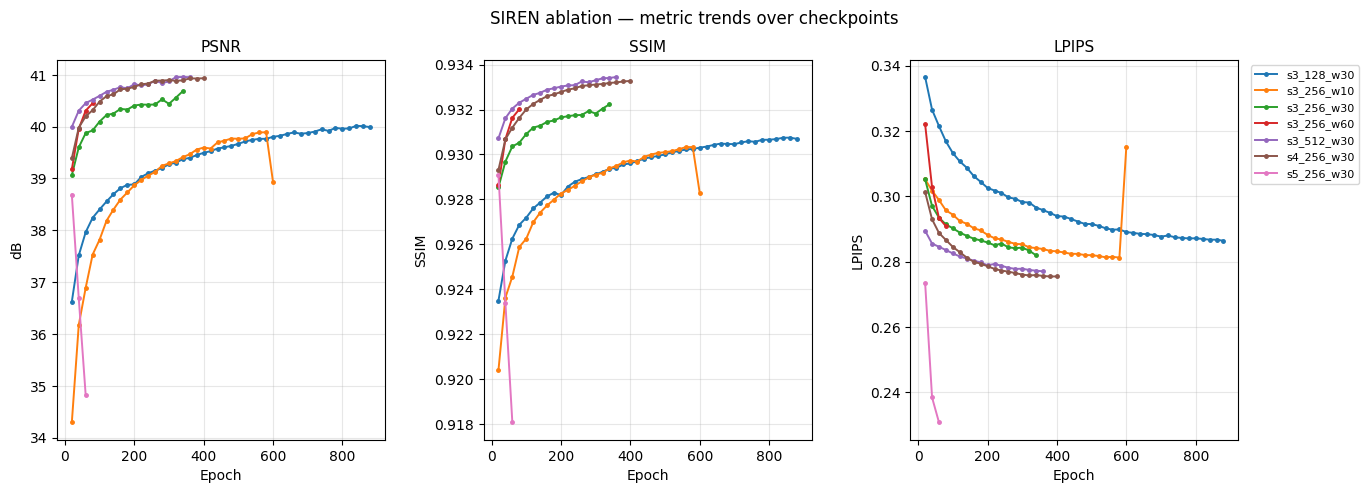

In [29]:
import re
from torchmetrics.functional.image import structural_similarity_index_measure as ssim_gpu

PRETRAINED  = dir_cfg['logs_dir']['siren']['root'] + 'pretrained'
infer_chunk = 2**20
lpips_idx   = list(range(0, D, max(1, D // 8)))[:8]  # 8 slices for speed

# ── constants (built once) ────────────────────────────────────────────────────
zc, yc, xc = (torch.linspace(-1, 1, s) for s in (D, H, W))
zz, yy, xx  = torch.meshgrid(zc, yc, xc, indexing='ij')
coords_cu   = torch.stack([zz, yy, xx], dim=-1).view(-1, 3).cuda()
gt_gpu      = volume.squeeze(0).cuda()                          # (D,H,W)
gt_lpips_b  = (gt_gpu[lpips_idx]
               .unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1)       # (8,3,H,W)

# ── colour palette (one per model) ───────────────────────────────────────────
palette = plt.cm.tab10.colors
model_names = sorted(loaded_models.keys())

# ── trend collection ─────────────────────────────────────────────────────────
all_trends = {}  # {model_name: {epochs: [], PSNR: [], SSIM: [], LPIPS: []}}

for m_idx, model_name in enumerate(model_names):
    ckpt_dir = os.path.join(PRETRAINED, model_name, 'checkpoints')
    epoch_ckpts = sorted(
        [f for f in os.listdir(ckpt_dir) if re.search(r'_epoch_\d+\.pth$', f)],
        key=lambda f: int(re.search(r'_epoch_(\d+)\.pth$', f).group(1))
    )
    epochs_x = [int(re.search(r'_epoch_(\d+)\.pth$', f).group(1)) for f in epoch_ckpts]

    # re-use architecture from loaded_models
    model = loaded_models[model_name]
    t_psnr, t_ssim, t_lpips = [], [], []

    for ckpt_file in epoch_ckpts:
        sd = torch.load(os.path.join(ckpt_dir, ckpt_file), map_location='cpu')
        sd = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
        model.load_state_dict(sd)
        model.cuda().eval()

        preds = []
        with torch.no_grad(), torch.amp.autocast('cuda'):
            for i in range(0, len(coords_cu), infer_chunk):
                preds.append(model(coords_cu[i:i+infer_chunk]).squeeze(-1))
        rec = torch.cat(preds).reshape(D, H, W).float()

        mse = ((rec - gt_gpu) ** 2).mean().item()
        t_psnr.append(-10 * np.log10(mse + 1e-8))
        t_ssim.append(ssim_gpu(rec.unsqueeze(1), gt_gpu.unsqueeze(1),
                               data_range=1.0).item())
        rec_lb = (rec[lpips_idx].unsqueeze(1).repeat(1, 3, 1, 1) * 2 - 1)
        with torch.no_grad():
            t_lpips.append(loss_fn_lpips(gt_lpips_b, rec_lb).mean().item())

        del rec, rec_lb
        torch.cuda.empty_cache()

    model.cpu()
    all_trends[model_name] = dict(epochs=epochs_x, PSNR=t_psnr, SSIM=t_ssim, LPIPS=t_lpips)
    print(f"{model_name}  done ({len(epoch_ckpts)} checkpoints)")

# restore best weights in loaded_models
for model_name, model in loaded_models.items():
    ckpt_dir = os.path.join(PRETRAINED, model_name, 'checkpoints')
    best = [f for f in os.listdir(ckpt_dir) if f.endswith('_best.pth')]
    sd = torch.load(os.path.join(ckpt_dir, best[0]), map_location='cpu')
    sd = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
    model.load_state_dict(sd)
    model.eval()

# ── trend plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.subplots_adjust(wspace=0.3, top=0.88, bottom=0.12, right=0.82)

metrics = [('PSNR', 'dB'), ('SSIM', 'SSIM'), ('LPIPS', 'LPIPS')]
kw = dict(linewidth=1.4, markersize=2.5, marker='o')

for ax, (metric, ylabel) in zip(axes, metrics):
    for m_idx, model_name in enumerate(model_names):
        tr = all_trends[model_name]
        ax.plot(tr['epochs'], tr[metric],
                color=palette[m_idx], label=model_name, **kw)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left',
                fontsize=8, framealpha=0.8)
fig.suptitle('SIREN ablation — metric trends over checkpoints', fontsize=12)
os.makedirs(dir_cfg['logs_dir']['siren']['analysis'], exist_ok=True)
plt.savefig(dir_cfg['logs_dir']['siren']['analysis'] + 'ablation_trends.pdf',
            bbox_inches='tight')
plt.show()
